# R5 - Efecto de la representación de entrada (condiciones A, B y C)

Evalúa de forma controlada el efecto de la representación de entrada sobre el desempeño de las arquitecturas CNN, manteniendo constante el protocolo de entrenamiento y evaluación:

- **A - imagen completa:** la ecografía original.
- **B - ROI automática:** región de interés obtenida a partir de la máscara predicha por el segmentador U-Net baseline fijo. Incorpora el error real del segmentador.
- **C - ROI de referencia:** región de interés obtenida a partir de la máscara de referencia. Es una condición idealizada que sirve como referencia experimental y no constituye una alternativa operativa.

El objetivo es cuantificar el efecto de cambiar la representación de entrada, no seleccionar la solución final: no se realizan rankings, pruebas de significancia ni selección de arquitectura. Todas las métricas se calculan sobre `validation` (200 imágenes: 178 benignas y 22 malignas). **El conjunto `test` no se utiliza.**

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score


def locate_project_root() -> Path:
    current_dir = Path.cwd().resolve()

    for candidate in [current_dir, *current_dir.parents]:
        if (
            (candidate / "src").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto."
    )


PROJECT_ROOT = locate_project_root()

## 1. Configuración

Los parámetros del análisis replican los de R4 y se fijaron antes de observar los resultados de B y C.

In [2]:
CLASSIFICATION_DIR = PROJECT_ROOT / "results" / "classification"
OUTPUT_DIR = CLASSIFICATION_DIR / "r5_input_representation" / "analysis"
FIGURES_DIR = OUTPUT_DIR / "figures"
R4_BOOTSTRAP_MEANS = CLASSIFICATION_DIR / "r4_benchmark" / "analysis" / "r4_bootstrap_means.csv"
SPLIT_CSV = PROJECT_ROOT / "configs" / "splits" / "mmotu_experimental_split_standard.csv"

ARCHS = ["resnet50", "densenet121", "convnext_tiny"]
CONDITIONS = ["A", "B", "C"]
SEEDS = [42, 43, 44]

# Origen de cada condición (A se lee de R4, B y C de R5)
CONDITION_SOURCES = {
    "A": {"experiment": "r4_benchmark", "image_dir": "data/processed/MMOTU_OTU_2D_experimental"},
    "B": {"experiment": "r5_input_representation", "image_dir": "data/processed/MMOTU_OTU_2D_roi_pred"},
    "C": {"experiment": "r5_input_representation", "image_dir": "data/processed/MMOTU_OTU_2D_roi_gt"},
}

METRICS = ["roc_auc", "average_precision", "sensitivity", "specificity"]
CONTRASTS = [("B", "A"), ("C", "A"), ("B", "C")]

THRESHOLD = 0.5
N_BOOTSTRAP = 2000
BOOTSTRAP_SEED = 2026
CI_PERCENTILES = (2.5, 97.5)

N_VALIDATION = 200
N_MALIGNANT = 22
N_BENIGN = 178

ARCH_LABELS = {"resnet50": "ResNet50", "densenet121": "DenseNet121", "convnext_tiny": "ConvNeXt-Tiny"}
CONDITION_LABELS = {"A": "A: imagen completa", "B": "B: ROI automática (U-Net)", "C": "C: ROI de referencia"}
METRIC_LABELS = {
    "roc_auc": "ROC-AUC",
    "average_precision": "Average Precision",
    "sensitivity": "Sensibilidad",
    "specificity": "Especificidad",
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def run_dir(arch, condition, seed):
    experiment = CONDITION_SOURCES[condition]["experiment"]
    return CLASSIFICATION_DIR / experiment / arch / condition / f"seed_{seed}"


COMBINATIONS = [(arch, condition, seed) for arch in ARCHS for condition in CONDITIONS for seed in SEEDS]
assert len(COMBINATIONS) == 27

## 2. Validación de las 27 corridas

Se comprueba, para cada combinación arquitectura × condición × semilla, que la corrida existe y que su configuración corresponde al protocolo común de R4/R5. Solo pueden diferir, según la condición, el experimento de origen y el directorio de imágenes. Si una comprobación falla, el notebook se detiene indicando la combinación responsable.

In [3]:
class ValidationError(Exception):
    pass


def require(condition_ok, combination, message):
    if not condition_ok:
        arch, condition, seed = combination
        raise ValidationError(f"[{arch} | condición {condition} | seed {seed}] {message}")


REQUIRED_FILES = ["run_config.json", "best_auc_meta.json", "validation_metrics.json", "val_predictions_best_auc.csv"]

COMMON_PROTOCOL = {
    "seed_source": "cli_override",
    "learning_rate_source": "yaml",
    "optimizer": "AdamW",
    "batch_size": 32,
    "epochs_max": 30,
    "patience": 5,
    "threshold": 0.5,
    "pretrained": True,
    "freeze_backbone": False,
    "num_classes": 2,
    "scheduler": None,
    "train_samples": 800,
    "validation_samples": N_VALIDATION,
    "checkpoint_criterion": "max val_roc_auc (first epoch among ties)",
    "checkpoint_file": "best_auc.pth",
    "early_stopping_criterion": "val_weighted_loss (patience=5, min_delta=0.001)",
    "val_predictions": "val_predictions_best_auc.csv",
}
COMMON_FLOATS = {"learning_rate": 1e-4, "weight_decay": 1e-4, "min_delta": 0.001}

run_configs = {}
best_metas = {}

for combination in COMBINATIONS:
    arch, condition, seed = combination
    directory = run_dir(arch, condition, seed)

    require(directory.is_dir(), combination, f"no existe la carpeta {directory}")
    for filename in REQUIRED_FILES:
        require((directory / filename).is_file(), combination, f"falta {filename}")

    with open(directory / "run_config.json") as f:
        config = json.load(f)
    with open(directory / "best_auc_meta.json") as f:
        meta = json.load(f)

    require(config["architecture"] == arch, combination, f"architecture={config['architecture']}")
    require(config["condition"] == condition, combination, f"condition={config['condition']}")
    require(config["seed"] == seed, combination, f"seed={config['seed']}")
    require(config["experiment"] == CONDITION_SOURCES[condition]["experiment"], combination, f"experiment={config['experiment']}")
    require(config["image_dir"] == CONDITION_SOURCES[condition]["image_dir"], combination, f"image_dir={config['image_dir']}")

    for key, expected in COMMON_PROTOCOL.items():
        require(config.get(key) == expected, combination, f"{key}={config.get(key)!r}, se esperaba {expected!r}")
    for key, expected in COMMON_FLOATS.items():
        require(np.isclose(config[key], expected, rtol=0, atol=1e-12), combination, f"{key}={config[key]}")

    # Checkpoint seleccionado por max val_roc_auc
    require(meta.get("criterion") == "max val_roc_auc", combination, f"criterio del checkpoint: {meta.get('criterion')}")
    require(meta["epoch"] == config["epoch_best"], combination, "epoch del meta distinta de epoch_best")
    require(np.isclose(meta["val_roc_auc"], config["val_roc_auc_best"], rtol=0, atol=1e-12), combination, "val_roc_auc del meta distinta de run_config")

    run_configs[combination] = config
    best_metas[combination] = meta

# Elementos que deben ser idénticos en las 27 corridas
for key in ["class_weights", "csv_path"]:
    values = {json.dumps(config[key]) for config in run_configs.values()}
    if len(values) != 1:
        raise ValidationError(f"{key} difiere entre corridas: {values}")

print("Corridas validadas:", len(run_configs), "/ 27")

Corridas validadas: 27 / 27


## 3. Predicciones de validation

Se comprueba que las 27 corridas contienen exactamente las mismas 200 imágenes de `validation`, con los mismos `image_id`, en el mismo orden y con las mismas etiquetas (178 benignas y 22 malignas), y que ninguna imagen pertenece a `test`. Las métricas recalculadas desde las probabilidades deben coincidir con `validation_metrics.json`.

In [4]:
def compute_metrics(y_true, y_prob, threshold=THRESHOLD):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    positives = y_true == 1
    negatives = y_true == 0

    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "sensitivity": float((y_pred[positives] == 1).mean()),
        "specificity": float((y_pred[negatives] == 0).mean()),
    }


def complementary_metrics(y_true, y_prob, threshold=THRESHOLD):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)

    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return {
        "accuracy": (tp + tn) / len(y_true),
        "balanced_accuracy": (sensitivity + specificity) / 2,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


split_df = pd.read_csv(SPLIT_CSV)
validation_ids = set(split_df.loc[split_df["experimental_split"] == "validation", "image_id"])
test_ids = set(split_df.loc[split_df["experimental_split"] == "test", "image_id"])

predictions = {}
reference = None

for combination in COMBINATIONS:
    df = pd.read_csv(run_dir(*combination) / "val_predictions_best_auc.csv")

    require(list(df.columns) == ["epoch", "image_id", "y_true", "probability_malignant"], combination, "columnas inesperadas")
    require(len(df) == N_VALIDATION, combination, f"{len(df)} filas")
    require(df["epoch"].nunique() == 1 and int(df["epoch"].iloc[0]) == run_configs[combination]["epoch_best"],
            combination, "la época de las predicciones no es la del checkpoint seleccionado")
    require(df["image_id"].is_unique, combination, "image_id repetidos")
    require(set(df["image_id"]) == validation_ids, combination, "los image_id no son los de validation")
    require(not (set(df["image_id"]) & test_ids), combination, "contiene imágenes de test")
    require(df["probability_malignant"].between(0.0, 1.0).all(), combination, "probabilidades fuera de [0, 1]")

    if reference is None:
        reference = df[["image_id", "y_true"]].copy()
    else:
        require(df["image_id"].tolist() == reference["image_id"].tolist(), combination, "orden de image_id distinto")
        require(df["y_true"].tolist() == reference["y_true"].tolist(), combination, "etiquetas y_true distintas")

    predictions[combination] = df["probability_malignant"].to_numpy()

y_true = reference["y_true"].to_numpy()
assert int((y_true == 1).sum()) == N_MALIGNANT and int((y_true == 0).sum()) == N_BENIGN

# Comprobación cruzada con validation_metrics.json
JSON_KEYS = {
    "roc_auc": "roc_auc", "average_precision": "average_precision",
    "sensitivity": "recall_malignant", "specificity": "specificity",
    "accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
}

for combination, y_prob in predictions.items():
    with open(run_dir(*combination) / "validation_metrics.json") as f:
        saved = json.load(f)

    recomputed = {**compute_metrics(y_true, y_prob), **complementary_metrics(y_true, y_prob)}
    for metric, json_key in JSON_KEYS.items():
        require(abs(recomputed[metric] - saved[json_key]) < 1e-6, combination,
                f"{metric} recalculada={recomputed[metric]:.6f} != validation_metrics.json={saved[json_key]:.6f}")

    cm = [[recomputed["tn"], recomputed["fp"]], [recomputed["fn"], recomputed["tp"]]]
    require(cm == saved["confusion_matrix"], combination, "matriz de confusión distinta de validation_metrics.json")

print("Predicciones: 27 corridas con las mismas 200 imágenes de validation, mismo orden y mismas etiquetas")
print("Benignas:", int((y_true == 0).sum()), "| Malignas:", int((y_true == 1).sum()), "| imágenes de test: 0")

Predicciones: 27 corridas con las mismas 200 imágenes de validation, mismo orden y mismas etiquetas
Benignas: 178 | Malignas: 22 | imágenes de test: 0


In [5]:
run_validation = pd.DataFrame(
    [
        {
            "architecture": arch,
            "condition": condition,
            "seed": seed,
            "experiment": run_configs[(arch, condition, seed)]["experiment"],
            "image_dir": run_configs[(arch, condition, seed)]["image_dir"],
            "epoch_best": run_configs[(arch, condition, seed)]["epoch_best"],
            "epochs_run": run_configs[(arch, condition, seed)]["epochs_run"],
            "early_stopped": run_configs[(arch, condition, seed)]["early_stopped"],
            "protocol_check": "ok",
            "predictions_check": "ok",
            "metrics_crosscheck": "ok",
        }
        for arch, condition, seed in COMBINATIONS
    ]
)

run_validation.to_csv(OUTPUT_DIR / "r5_run_validation.csv", index=False)

run_validation

,architecture,condition,seed,experiment,image_dir,epoch_best,epochs_run,early_stopped,protocol_check,predictions_check,metrics_crosscheck
0,resnet50,A,42,r4_benchmark,data/processed/MMOTU_OTU_2D_experimental,6,7,True,ok,ok,ok
1,resnet50,A,43,r4_benchmark,data/processed/MMOTU_OTU_2D_experimental,7,9,True,ok,ok,ok
2,resnet50,A,44,r4_benchmark,data/processed/MMOTU_OTU_2D_experimental,5,6,True,ok,ok,ok
3,resnet50,B,42,r5_input_representation,data/processed/MMOTU_OTU_2D_roi_pred,4,6,True,ok,ok,ok
4,resnet50,B,43,r5_input_representation,data/processed/MMOTU_OTU_2D_roi_pred,5,6,True,ok,ok,ok
5,resnet50,B,44,r5_input_representation,data/processed/MMOTU_OTU_2D_roi_pred,5,6,True,ok,ok,ok
6,resnet50,C,42,r5_input_representation,data/processed/MMOTU_OTU_2D_roi_gt,5,6,True,ok,ok,ok
7,resnet50,C,43,r5_input_representation,data/processed/MMOTU_OTU_2D_roi_gt,5,6,True,ok,ok,ok
8,resnet50,C,44,r5_input_representation,data/processed/MMOTU_OTU_2D_roi_gt,6,6,True,ok,ok,ok
9,densenet121,A,42,r4_benchmark,data/processed/MMOTU_OTU_2D_experimental,7,8,True,ok,ok,ok


### Cobertura de la lesión por la región de interés

Para cada muestra de `train` y `validation` de las condiciones B y C se mide qué parte de la lesión de referencia queda dentro del recorte que recibe la CNN:

`cobertura = píxeles de la máscara de referencia dentro del bounding box de la ROI / píxeles totales de la máscara de referencia`

- La medición se realiza en las **coordenadas de la imagen original**, antes de `ResizeWithPadding(224)`.
- El bounding box de cada ROI se recalcula a partir de la máscara persistida con la misma lógica de extracción de ROI (B: máscara predicha, componente mayor, fallback; C: máscara de referencia, todas las componentes, sin fallback) y se comprueba que sus dimensiones y su indicador de fallback coinciden con el manifiesto de la ROI ya materializada. No se genera ni se modifica ninguna ROI.
- En los casos de fallback de B la entrada es la imagen completa, por lo que la cobertura debe ser 1.0.
- En C se verifica numéricamente que el recorte conserva la lesión completa (cobertura exactamente 1.0); no se asume.
- La cobertura de B depende de la calidad del segmentador y puede diferir entre `train` y `validation` (el segmentador se ajustó con las imágenes de `train`).

In [6]:
import sys

from PIL import Image

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.segmentation.roi import (
    MIN_COMPONENT_AREA_FRACTION,
    expand_bbox,
    keep_largest_component,
    mask_to_bbox,
    resize_mask_to_image,
)

COVERAGE_CONDITIONS = ["B", "C"]
COVERAGE_SPLITS = ["train", "validation"]  # test no se utiliza
ROI_MARGIN_RATIO = 0.10

EXPERIMENTAL_DIR = PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_experimental"
PRED_MASKS_ROOT = PROJECT_ROOT / "results" / "segmentation" / "unet_baseline"
ROI_MANIFESTS = {
    "B": CLASSIFICATION_DIR / "roi_generation" / "manifest_B_roi_pred.csv",
    "C": CLASSIFICATION_DIR / "roi_generation" / "manifest_C_roi_gt.csv",
}

image_names = {
    split: split_df[split_df["experimental_split"] == split].set_index("image_id")["image_name"]
    for split in COVERAGE_SPLITS
}


def roi_bbox(condition, mask_binary, image_size):
    """Bounding box de la ROI (left, top, right, bottom) en coordenadas de la imagen original y fallback."""
    width, height = image_size
    resized = resize_mask_to_image(mask_binary, image_size=image_size)

    if condition == "B":
        used = keep_largest_component(resized)
        if used.sum() == 0 or used.sum() / (width * height) < MIN_COMPONENT_AREA_FRACTION:
            return (0, 0, width, height), True
    else:
        used = resized  # todas las componentes, sin fallback
        if used.sum() == 0:
            raise ValueError("máscara de referencia vacía")

    return expand_bbox(mask_to_bbox(used), image_size, ROI_MARGIN_RATIO), False


coverage_records = []

for condition in COVERAGE_CONDITIONS:
    manifest = pd.read_csv(ROI_MANIFESTS[condition], dtype={"image_id": int})

    for split in COVERAGE_SPLITS:
        rows = manifest[manifest["split"] == split].sort_values("image_id")
        assert len(rows) == (800 if split == "train" else 200), (condition, split, len(rows))

        for row in rows.to_dict("records"):
            image_id = int(row["image_id"])
            where = f"[{condition} | {split} | image_id={image_id}]"
            image_name = image_names[split].loc[image_id]

            with Image.open(EXPERIMENTAL_DIR / split / "images" / image_name) as image:
                image_size = image.size  # (ancho, alto)

            with Image.open(EXPERIMENTAL_DIR / split / "masks" / f"{Path(image_name).stem}_binary.PNG") as mask:
                reference_mask = (np.asarray(mask.convert("L")) > 0).astype(np.uint8)
            if reference_mask.shape != (image_size[1], image_size[0]):
                raise ValueError(f"{where} la máscara de referencia no tiene el tamaño de la imagen")
            if reference_mask.sum() == 0:
                raise ValueError(f"{where} máscara de referencia vacía")

            if condition == "B":
                mask_path = PRED_MASKS_ROOT / split / "predicted_masks" / f"{image_id}_pred.png"
                with Image.open(mask_path) as predicted:
                    segmentation_mask = (np.asarray(predicted.convert("L")) > 0).astype(np.uint8)
            else:
                segmentation_mask = reference_mask

            bbox, fallback = roi_bbox(condition, segmentation_mask, image_size)

            # La geometría recalculada debe corresponder a la ROI materializada
            roi_size = (bbox[2] - bbox[0], bbox[3] - bbox[1])
            if roi_size != (int(row["roi_width"]), int(row["roi_height"])) or fallback != bool(row["used_fallback"]):
                raise ValueError(
                    f"{where} bbox recalculado {roi_size} (fallback={fallback}) distinto del manifiesto "
                    f"{(row['roi_width'], row['roi_height'])} (fallback={row['used_fallback']})"
                )

            left, top, right, bottom = bbox
            coverage = float(reference_mask[top:bottom, left:right].sum() / reference_mask.sum())

            coverage_records.append(
                {"image_id": image_id, "split": split, "condition": condition, "coverage": coverage, "fallback": fallback}
            )

lesion_coverage = pd.DataFrame(coverage_records)
assert len(lesion_coverage) == 2 * (800 + 200)

# Fallback de B: la entrada es la imagen completa -> cobertura 1.0
b_fallback = lesion_coverage[(lesion_coverage["condition"] == "B") & lesion_coverage["fallback"]]
assert (b_fallback["coverage"] == 1.0).all(), b_fallback

# C: el recorte basado en todas las componentes conserva la lesión completa
c_rows = lesion_coverage[lesion_coverage["condition"] == "C"]
incomplete = c_rows[c_rows["coverage"] < 1.0]
assert not c_rows["fallback"].any(), "fallback en C"
assert incomplete.empty, f"C no conserva la lesión completa en image_id: {incomplete['image_id'].tolist()}"

lesion_coverage.to_csv(OUTPUT_DIR / "r5_lesion_coverage.csv", index=False)

print("Muestras:", len(lesion_coverage), "| fallbacks de B:", len(b_fallback), "| C con lesión completa: ", len(c_rows) - len(incomplete), "/", len(c_rows))

Muestras: 2000 | fallbacks de B: 2 | C con lesión completa:  1000 / 1000


In [7]:
coverage_summary = (
    lesion_coverage
    .groupby(["condition", "split"])["coverage"]
    .agg(
        N="count",
        media="mean",
        mediana="median",
        minimo="min",
        pct_cobertura_ge_095=lambda values: 100 * (values >= 0.95).mean(),
        pct_cobertura_igual_1=lambda values: 100 * (values == 1.0).mean(),
    )
    .reset_index()
)

coverage_summary

,condition,split,N,media,mediana,minimo,pct_cobertura_ge_095,pct_cobertura_igual_1
0,B,train,800,0.996819,1.0,0.575834,98.5,95.875
1,B,validation,200,0.874343,1.0,0.000000,72.0,58.500
2,C,train,800,1.000000,1.0,1.000000,100.0,100.000
3,C,validation,200,1.000000,1.0,1.000000,100.0,100.000


**Control diagnóstico (B, validation).** Los cinco casos con menor cobertura de la lesión de referencia por la ROI automática:

In [8]:
(
    lesion_coverage[(lesion_coverage["condition"] == "B") & (lesion_coverage["split"] == "validation")]
    .sort_values("coverage")
    .head(5)
    .reset_index(drop=True)
)

,image_id,split,condition,coverage,fallback
0,107,validation,B,0.0,False
1,347,validation,B,0.0,False
2,599,validation,B,0.0,False
3,651,validation,B,0.0,False
4,704,validation,B,0.0,False


## Visualización cualitativa de las representaciones A, B y C

Antes del análisis cuantitativo se muestran ejemplos de las tres representaciones de entrada sobre las mismas imágenes de `validation`. Las figuras usan los archivos ya existentes (imagen completa, ROI de B y ROI de C) y no aplican augmentation; no se genera ni se guarda ninguna imagen nueva del conjunto de datos.

**Selección de ejemplos.** Se eligen 3 imágenes benignas y 3 malignas de `validation` con un generador de semilla fija (`default_rng(2026)`), sobre los `image_id` ordenados de forma ascendente. La selección no utiliza ninguna información de desempeño del clasificador ni del segmentador.

In [8]:
import sys

from PIL import Image

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.classification.transforms import ResizeWithPadding
from src.segmentation.roi import keep_largest_component, resize_mask_to_image

QUALITATIVE_SEED = 2026
N_EXAMPLES_PER_CLASS = 3

EXPERIMENTAL_DIR = PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_experimental"
ROI_DIRS = {
    "B": PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_roi_pred",
    "C": PROJECT_ROOT / "data" / "processed" / "MMOTU_OTU_2D_roi_gt",
}
PRED_MASKS_DIR = PROJECT_ROOT / "results" / "segmentation" / "unet_baseline" / "validation" / "predicted_masks"
MANIFEST_B = CLASSIFICATION_DIR / "roi_generation" / "manifest_B_roi_pred.csv"

COLUMN_TITLES = {"A": "A - Imagen completa", "B": "B - ROI automática", "C": "C - ROI de referencia"}
CLASS_NAMES = {0: "benigna", 1: "maligna"}

validation_images = (
    split_df[split_df["experimental_split"] == "validation"]
    .set_index("image_id")["image_name"]
)


def load_representation(image_id, condition):
    if condition == "A":
        path = EXPERIMENTAL_DIR / "validation" / "images" / validation_images.loc[image_id]
    else:
        path = ROI_DIRS[condition] / "validation" / "images" / f"{image_id}.png"
    with Image.open(path) as image:
        return image.convert("RGB")


def show_on_canvas(ax, image, canvas_size):
    """Muestra la imagen a escala real de píxeles, centrada en un lienzo del tamaño de la imagen completa."""
    canvas_width, canvas_height = canvas_size
    width, height = image.size
    x0 = (canvas_width - width) / 2
    y0 = (canvas_height - height) / 2

    ax.imshow(image, extent=(x0, x0 + width, y0 + height, y0))
    ax.set_xlim(0, canvas_width)
    ax.set_ylim(canvas_height, 0)
    ax.set_facecolor("white")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("#cccccc")


labels_by_id = reference.set_index("image_id")["y_true"]
rng_examples = np.random.default_rng(QUALITATIVE_SEED)

example_ids = []
for label in (0, 1):
    candidates = np.sort(labels_by_id[labels_by_id == label].index.to_numpy())
    chosen = rng_examples.choice(candidates, size=N_EXAMPLES_PER_CLASS, replace=False)
    example_ids.extend(int(image_id) for image_id in np.sort(chosen))

print("Ejemplos seleccionados:", [(image_id, CLASS_NAMES[int(labels_by_id[image_id])]) for image_id in example_ids])

Ejemplos seleccionados: [(19, 'benigna'), (232, 'benigna'), (1119, 'benigna'), (215, 'maligna'), (832, 'maligna'), (895, 'maligna')]


### Figura 1. Representaciones A, B y C sobre las mismas imágenes

Cada fila corresponde a un mismo `image_id`. Las tres representaciones se dibujan **a la misma escala de píxeles**, sobre un lienzo del tamaño de la imagen completa, de modo que se aprecia cuánto contexto conserva A y cuánto recortan B y C. El tamaño en píxeles de cada entrada se indica bajo cada panel.

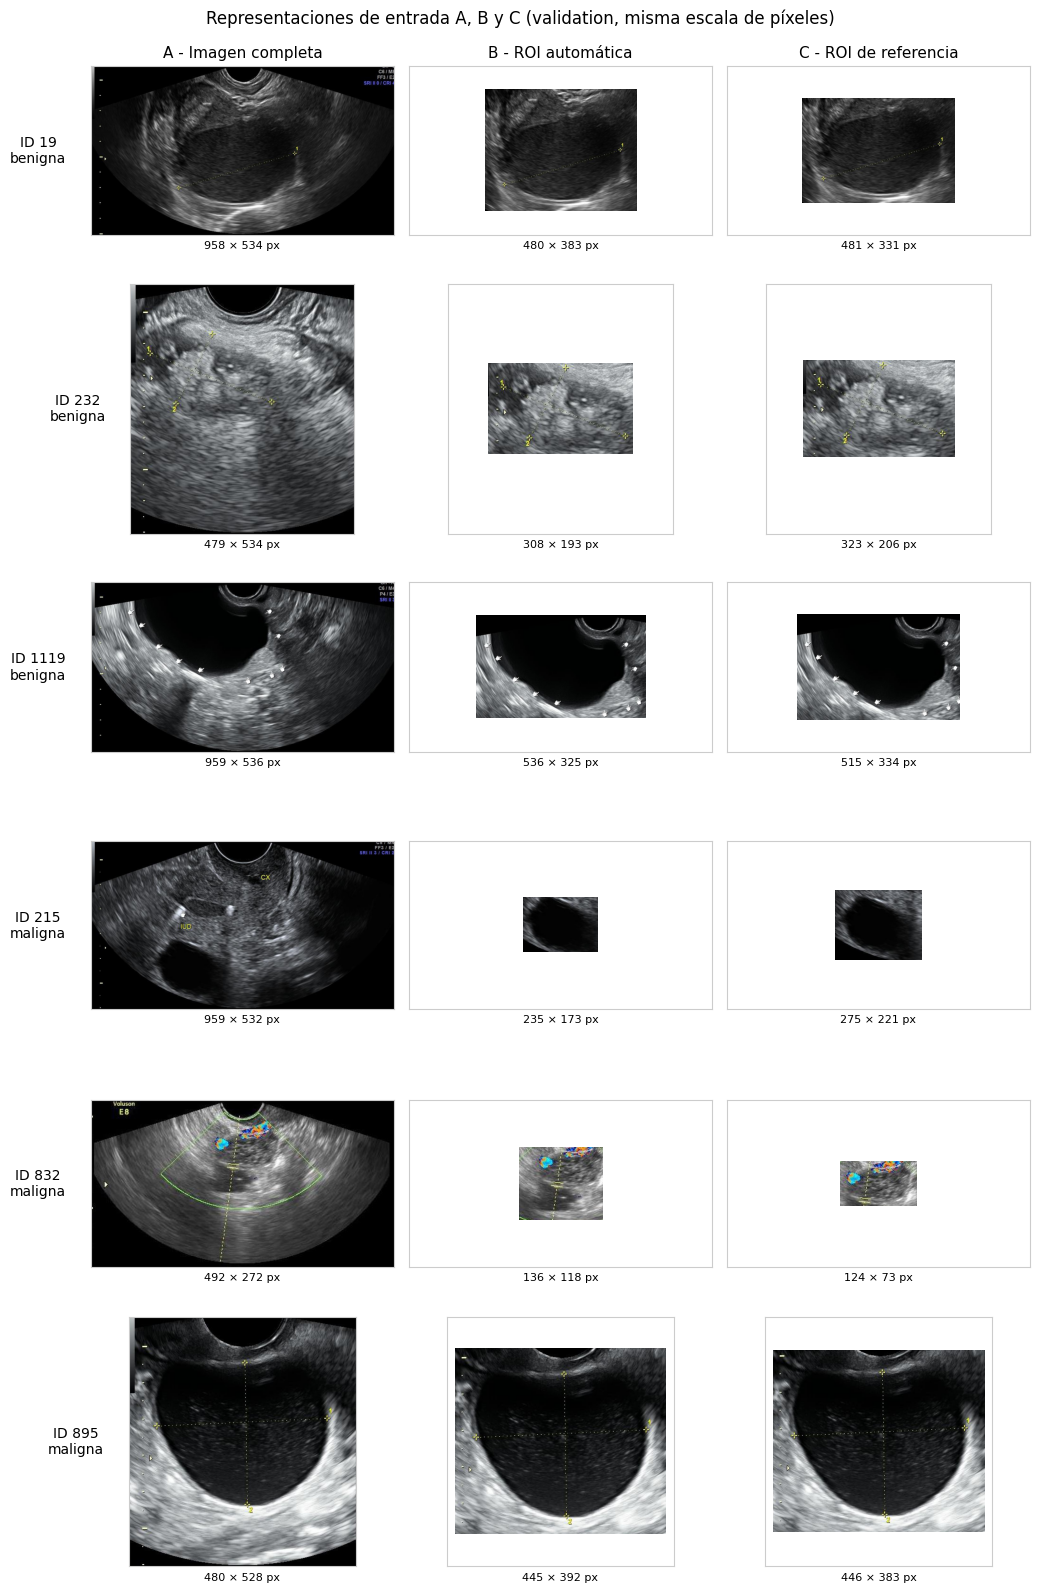

In [9]:
fig, axes = plt.subplots(len(example_ids), 3, figsize=(10.5, 2.7 * len(example_ids)))

for row, image_id in enumerate(example_ids):
    images = {condition: load_representation(image_id, condition) for condition in CONDITIONS}
    canvas_size = images["A"].size

    for col, condition in enumerate(CONDITIONS):
        ax = axes[row, col]
        show_on_canvas(ax, images[condition], canvas_size)
        width, height = images[condition].size
        ax.set_xlabel(f"{width} × {height} px", fontsize=8)
        if row == 0:
            ax.set_title(COLUMN_TITLES[condition], fontsize=11)

    axes[row, 0].set_ylabel(
        f"ID {image_id}\n{CLASS_NAMES[int(labels_by_id[image_id])]}",
        fontsize=10, rotation=0, labelpad=38, va="center",
    )

fig.suptitle("Representaciones de entrada A, B y C (validation, misma escala de píxeles)", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "r5_examples_abc.png", dpi=300, bbox_inches="tight")
plt.show()

### Figura 2. Casos de fallback de B en validation (IDs 775 y 869)

En estos dos casos la componente mayor de la máscara predicha por el U-Net ocupa menos del 0.1 % del área de la imagen, por lo que B utiliza la imagen completa (fallback). Se muestran la imagen completa, la máscara predicha (llevada a la resolución original), la entrada efectivamente utilizada en B y la ROI de referencia de C.

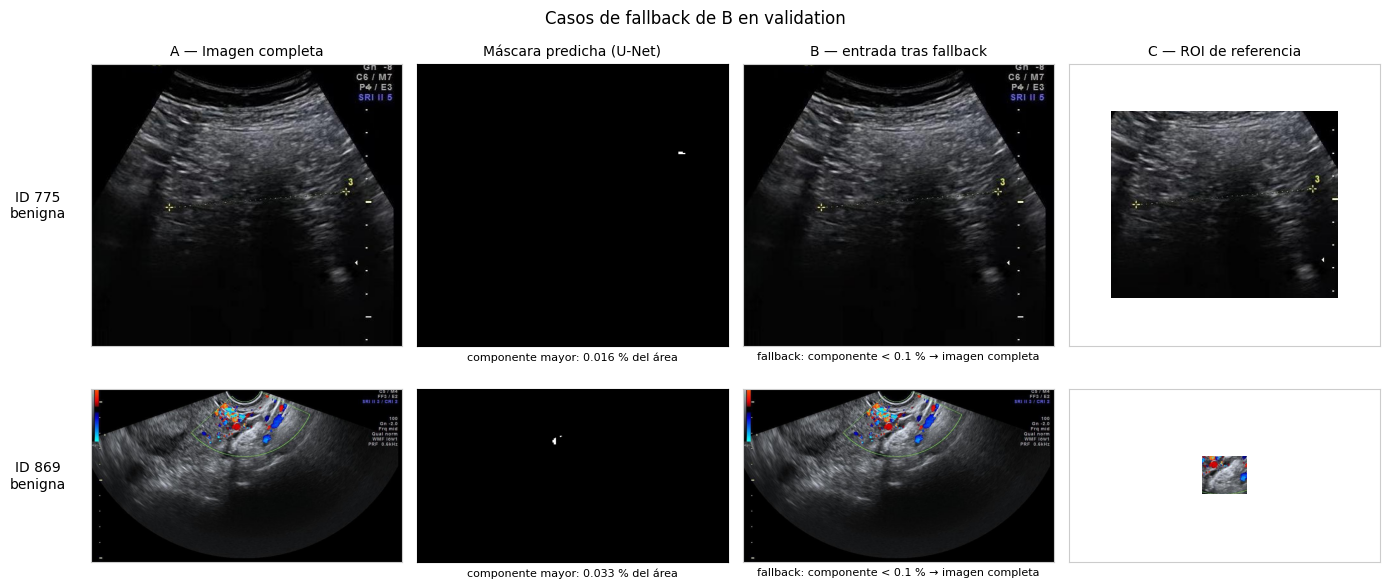

In [10]:
FALLBACK_IDS = [775, 869]
MIN_AREA_FRACTION = 0.001

manifest_b = pd.read_csv(MANIFEST_B)
for image_id in FALLBACK_IDS:
    row = manifest_b[(manifest_b["split"] == "validation") & (manifest_b["image_id"] == image_id)]
    assert len(row) == 1 and bool(row["used_fallback"].iloc[0]), f"ID {image_id} no figura como fallback en el manifiesto de B"

fig, axes = plt.subplots(len(FALLBACK_IDS), 4, figsize=(14.0, 3.2 * len(FALLBACK_IDS)))
column_titles = ["A — Imagen completa", "Máscara predicha (U-Net)", "B — entrada tras fallback", "C — ROI de referencia"]

for row, image_id in enumerate(FALLBACK_IDS):
    image_a = load_representation(image_id, "A")
    image_b = load_representation(image_id, "B")
    image_c = load_representation(image_id, "C")
    canvas_size = image_a.size

    with Image.open(PRED_MASKS_DIR / f"{image_id}_pred.png") as mask:
        mask_binary = (np.asarray(mask.convert("L")) > 0).astype(np.uint8)
    mask_original = resize_mask_to_image(mask_binary, image_size=canvas_size)
    largest_fraction = keep_largest_component(mask_original).sum() / (canvas_size[0] * canvas_size[1])

    assert image_b.size == image_a.size, f"ID {image_id}: la entrada de B no es la imagen completa"

    show_on_canvas(axes[row, 0], image_a, canvas_size)
    axes[row, 1].imshow(mask_original, cmap="gray", vmin=0, vmax=1, extent=(0, canvas_size[0], canvas_size[1], 0))
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    show_on_canvas(axes[row, 2], image_b, canvas_size)
    show_on_canvas(axes[row, 3], image_c, canvas_size)

    axes[row, 1].set_xlabel(f"componente mayor: {100 * largest_fraction:.3f} % del área", fontsize=8)
    axes[row, 2].set_xlabel("fallback: componente < 0.1 % → imagen completa", fontsize=8)
    axes[row, 0].set_ylabel(
        f"ID {image_id}\n{CLASS_NAMES[int(labels_by_id[image_id])]}",
        fontsize=10, rotation=0, labelpad=38, va="center",
    )
    assert largest_fraction < MIN_AREA_FRACTION

    if row == 0:
        for col, title in enumerate(column_titles):
            axes[row, col].set_title(title, fontsize=10)

fig.suptitle("Casos de fallback de B en validation", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "r5_fallback_examples_b.png", dpi=300, bbox_inches="tight")
plt.show()

### Figura 3. Entrada efectiva de la CNN (224 × 224)

Para 3 de los ejemplos anteriores (los dos primeros benignos y el primero maligno, por orden de selección) se muestra cada representación después de `ResizeWithPadding(224)`, el mismo paso de las transformaciones de validación, sin augmentation. Se omite la normalización ImageNet porque es una transformación lineal por canal que no cambia la geometría y dificulta la lectura visual.

La figura evidencia que las ROI no solo eliminan contexto: al llevarse a 224 × 224 modifican también la escala efectiva del contenido (la imagen completa se reduce, mientras que parte de las ROI se amplía).

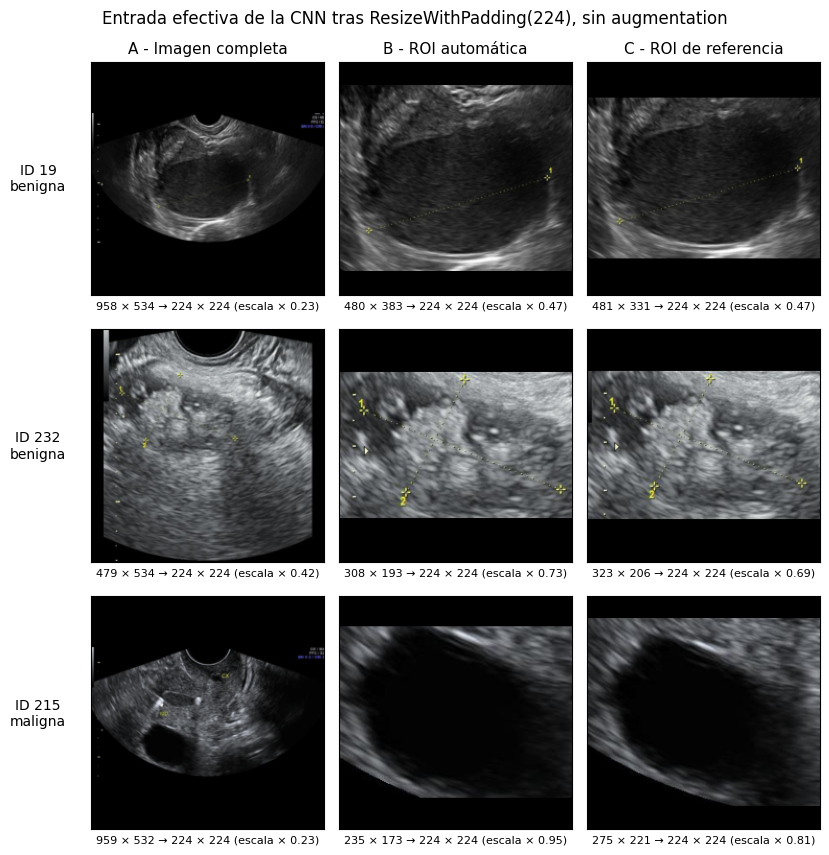

In [11]:
effective_ids = example_ids[:2] + example_ids[N_EXAMPLES_PER_CLASS:N_EXAMPLES_PER_CLASS + 1]
resize_with_padding = ResizeWithPadding(target_size=224)

fig, axes = plt.subplots(len(effective_ids), 3, figsize=(8.4, 2.9 * len(effective_ids)))

for row, image_id in enumerate(effective_ids):
    for col, condition in enumerate(CONDITIONS):
        original = load_representation(image_id, condition)
        resized = resize_with_padding(original)
        scale = min(224 / original.size[0], 224 / original.size[1])

        ax = axes[row, col]
        ax.imshow(resized)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(f"{original.size[0]} × {original.size[1]} → 224 × 224 (escala × {scale:.2f})", fontsize=8)
        if row == 0:
            ax.set_title(COLUMN_TITLES[condition], fontsize=11)

    axes[row, 0].set_ylabel(
        f"ID {image_id}\n{CLASS_NAMES[int(labels_by_id[image_id])]}",
        fontsize=10, rotation=0, labelpad=38, va="center",
    )

fig.suptitle("Entrada efectiva de la CNN tras ResizeWithPadding(224), sin augmentation", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "r5_examples_abc_224.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Resultados por semilla

ROC-AUC y Average Precision se calculan sobre las probabilidades; sensibilidad y especificidad con umbral 0.5. Accuracy, balanced accuracy y la matriz de confusión (`tn`, `fp`, `fn`, `tp`) se incluyen solo como información complementaria y de trazabilidad.

In [12]:
per_seed = pd.DataFrame(
    [
        {
            "architecture": arch,
            "condition": condition,
            "seed": seed,
            "epoch_best": run_configs[(arch, condition, seed)]["epoch_best"],
            **compute_metrics(y_true, predictions[(arch, condition, seed)]),
            **complementary_metrics(y_true, predictions[(arch, condition, seed)]),
        }
        for arch, condition, seed in COMBINATIONS
    ]
)

per_seed.to_csv(OUTPUT_DIR / "r5_metrics_per_seed.csv", index=False)

per_seed

,architecture,condition,seed,epoch_best,roc_auc,average_precision,sensitivity,specificity,accuracy,balanced_accuracy,tn,fp,fn,tp
0,resnet50,A,42,6,0.792901,0.414345,0.272727,0.955056,0.880,0.613892,170,8,16,6
1,resnet50,A,43,7,0.851124,0.562436,0.545455,0.943820,0.900,0.744637,168,10,10,12
2,resnet50,A,44,5,0.764045,0.368200,0.590909,0.769663,0.750,0.680286,137,41,9,13
3,resnet50,B,42,4,0.715526,0.272267,0.363636,0.848315,0.795,0.605975,151,27,14,8
4,resnet50,B,43,5,0.731103,0.363572,0.318182,0.876404,0.815,0.597293,156,22,15,7
5,resnet50,B,44,5,0.723442,0.377744,0.318182,0.938202,0.870,0.628192,167,11,15,7
6,resnet50,C,42,5,0.757661,0.361686,0.454545,0.915730,0.865,0.685138,163,15,12,10
7,resnet50,C,43,5,0.755873,0.408934,0.500000,0.910112,0.865,0.705056,162,16,11,11
8,resnet50,C,44,6,0.784219,0.390119,0.272727,0.960674,0.885,0.616701,171,7,16,6
9,densenet121,A,42,7,0.854188,0.482774,0.772727,0.848315,0.840,0.810521,151,27,5,17


## 5. Media y desviación estándar entre semillas

Para cada combinación arquitectura × condición se calcula la media de las 3 semillas y la desviación estándar muestral (`ddof = 1`).

In [7]:
seed_summary = (
    per_seed
    .melt(id_vars=["architecture", "condition", "seed"], value_vars=METRICS, var_name="metric", value_name="value")
    .groupby(["architecture", "condition", "metric"], sort=False)["value"]
    .agg(mean="mean", std_between_seeds=lambda values: values.std(ddof=1), n_seeds="count")
    .reset_index()
)

seed_summary

,architecture,condition,metric,mean,std_between_seeds,n_seeds
0,resnet50,A,roc_auc,0.802690,0.044357,3
1,resnet50,B,roc_auc,0.723357,0.007789,3
2,resnet50,C,roc_auc,0.765918,0.015874,3
3,densenet121,A,roc_auc,0.867041,0.017821,3
4,densenet121,B,roc_auc,0.772217,0.051460,3
5,densenet121,C,roc_auc,0.771110,0.019018,3
6,convnext_tiny,A,roc_auc,0.843378,0.036967,3
7,convnext_tiny,B,roc_auc,0.782431,0.026661,3
8,convnext_tiny,C,roc_auc,0.796136,0.053921,3
9,resnet50,A,average_precision,0.448327,0.101479,3


## 6. Índices bootstrap

Se usa el mismo procedimiento: remuestreo con reemplazo de las 200 imágenes de `validation`, estratificado por clase (22 malignas y 178 benignas en cada remuestreo);

In [8]:
malignant_positions = np.flatnonzero(y_true == 1)
benign_positions = np.flatnonzero(y_true == 0)

rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_indices = np.empty((N_BOOTSTRAP, N_VALIDATION), dtype=int)

for b in range(N_BOOTSTRAP):
    malignant_sample = rng.choice(malignant_positions, size=N_MALIGNANT, replace=True)
    benign_sample = rng.choice(benign_positions, size=N_BENIGN, replace=True)
    bootstrap_indices[b] = np.concatenate([malignant_sample, benign_sample])

assert ((y_true[bootstrap_indices] == 1).sum(axis=1) == N_MALIGNANT).all()
assert ((y_true[bootstrap_indices] == 0).sum(axis=1) == N_BENIGN).all()

print("Remuestreos:", bootstrap_indices.shape)

Remuestreos: (2000, 200)


## 7. Bootstrap de las medias por arquitectura y condición

En cada remuestreo se calcula cada métrica en las 3 semillas de una combinación arquitectura × condición, con los mismos índices, y se promedian. No se agrupan probabilidades entre semillas ni se construye un ensemble. Los percentiles 2.5 y 97.5 de las 2000 medias forman el IC 95 %.

In [9]:
bootstrap_values = np.empty((N_BOOTSTRAP, len(ARCHS), len(CONDITIONS), len(METRICS)))

for b, indices in enumerate(bootstrap_indices):
    y_true_b = y_true[indices]

    for i, arch in enumerate(ARCHS):
        for j, condition in enumerate(CONDITIONS):
            seed_values = [compute_metrics(y_true_b, predictions[(arch, condition, seed)][indices]) for seed in SEEDS]
            for k, metric in enumerate(METRICS):
                bootstrap_values[b, i, j, k] = np.mean([values[metric] for values in seed_values])

bootstrap_means = pd.DataFrame(
    [
        {
            "bootstrap_id": b,
            "architecture": arch,
            "condition": condition,
            "metric": metric,
            "value": bootstrap_values[b, i, j, k],
        }
        for b in range(N_BOOTSTRAP)
        for i, arch in enumerate(ARCHS)
        for j, condition in enumerate(CONDITIONS)
        for k, metric in enumerate(METRICS)
    ]
)

assert len(bootstrap_means) == N_BOOTSTRAP * len(ARCHS) * len(CONDITIONS) * len(METRICS)

bootstrap_means.to_csv(OUTPUT_DIR / "r5_bootstrap_means.csv", index=False)

bootstrap_means.head()

,bootstrap_id,architecture,condition,metric,value
0,0,resnet50,A,roc_auc,0.792390
1,0,resnet50,A,average_precision,0.358479
2,0,resnet50,A,sensitivity,0.409091
3,0,resnet50,A,specificity,0.893258
4,0,resnet50,B,roc_auc,0.681903


In [10]:
# Consistencia con R4: la condición A debe reproducir las medias bootstrap guardadas en R4
if R4_BOOTSTRAP_MEANS.exists():
    r4_means = pd.read_csv(R4_BOOTSTRAP_MEANS)
    a_means = (
        bootstrap_means[bootstrap_means["condition"] == "A"]
        .drop(columns="condition")
        .merge(r4_means, on=["bootstrap_id", "architecture", "metric"], suffixes=("_r5", "_r4"), validate="one_to_one")
    )
    assert len(a_means) == N_BOOTSTRAP * len(ARCHS) * len(METRICS)
    max_difference = (a_means["value_r5"] - a_means["value_r4"]).abs().max()
    assert max_difference < 1e-12, f"La condición A no reproduce el bootstrap de R4 (diferencia máxima {max_difference})"
    print("Condición A: medias bootstrap idénticas a las de R4")
else:
    print("No se encontró r4_bootstrap_means.csv; se omite la comparación con R4")

Condición A: medias bootstrap idénticas a las de R4


## 8. Tabla consolidada por arquitectura y condición

Para cada arquitectura × condición se reporta la media entre semillas, la desviación estándar entre semillas y el IC 95 % bootstrap de la media.

- La estimación de sensibilidad presenta una resolución discreta condicionada por los 22 casos malignos disponibles en `validation`.
- El IC refleja la incertidumbre por la muestra de `validation`; la variabilidad entre semillas se representa con la desviación estándar.

In [11]:
ci = (
    bootstrap_means
    .groupby(["architecture", "condition", "metric"], sort=False)["value"]
    .agg(
        ci95_lower=lambda values: np.percentile(values, CI_PERCENTILES[0]),
        ci95_upper=lambda values: np.percentile(values, CI_PERCENTILES[1]),
    )
    .reset_index()
)

summary = seed_summary.merge(ci, on=["architecture", "condition", "metric"], how="left", validate="one_to_one")
summary["n_bootstrap"] = N_BOOTSTRAP
summary["bootstrap_seed"] = BOOTSTRAP_SEED

order = {
    "architecture": {arch: i for i, arch in enumerate(ARCHS)},
    "condition": {condition: i for i, condition in enumerate(CONDITIONS)},
    "metric": {metric: i for i, metric in enumerate(METRICS)},
}
summary = summary.sort_values(
    ["architecture", "condition", "metric"], key=lambda column: column.map(order[column.name])
).reset_index(drop=True)

summary = summary[
    ["architecture", "condition", "metric", "mean", "std_between_seeds", "ci95_lower", "ci95_upper",
     "n_seeds", "n_bootstrap", "bootstrap_seed"]
]

assert len(summary) == len(ARCHS) * len(CONDITIONS) * len(METRICS)
assert summary[["mean", "std_between_seeds", "ci95_lower", "ci95_upper"]].notna().all().all()

summary.to_csv(OUTPUT_DIR / "r5_condition_summary.csv", index=False)

summary

,architecture,condition,metric,mean,std_between_seeds,ci95_lower,ci95_upper,n_seeds,n_bootstrap,bootstrap_seed
0,resnet50,A,roc_auc,0.802690,0.044357,0.712032,0.877520,3,2000,2026
1,resnet50,A,average_precision,0.448327,0.101479,0.325424,0.603649,3,2000,2026
2,resnet50,A,sensitivity,0.469697,0.172088,0.318182,0.606439,3,2000,2026
3,resnet50,A,specificity,0.889513,0.103945,0.857678,0.917603,3,2000,2026
4,resnet50,B,roc_auc,0.723357,0.007789,0.613451,0.817162,3,2000,2026
5,resnet50,B,average_precision,0.337861,0.057246,0.221083,0.502288,3,2000,2026
6,resnet50,B,sensitivity,0.333333,0.026243,0.181818,0.485227,3,2000,2026
7,resnet50,B,specificity,0.887640,0.045985,0.850187,0.919476,3,2000,2026
8,resnet50,C,roc_auc,0.765918,0.015874,0.654577,0.862958,3,2000,2026
9,resnet50,C,average_precision,0.386913,0.023786,0.262842,0.572370,3,2000,2026


In [12]:
summary_wide = summary.pivot(
    index=["architecture", "condition"],
    columns="metric",
    values=["mean", "std_between_seeds", "ci95_lower", "ci95_upper"],
)
summary_wide.columns = [f"{metric}_{statistic}" for statistic, metric in summary_wide.columns]
summary_wide = summary_wide[
    [f"{metric}_{statistic}" for metric in METRICS for statistic in ["mean", "std_between_seeds", "ci95_lower", "ci95_upper"]]
]
summary_wide = summary_wide.reindex(
    pd.MultiIndex.from_product([ARCHS, CONDITIONS], names=["architecture", "condition"])
).reset_index()

summary_wide.to_csv(OUTPUT_DIR / "r5_condition_summary_wide.csv", index=False)

summary_wide

,architecture,condition,roc_auc_mean,roc_auc_std_between_seeds,roc_auc_ci95_lower,roc_auc_ci95_upper,average_precision_mean,average_precision_std_between_seeds,average_precision_ci95_lower,average_precision_ci95_upper,sensitivity_mean,sensitivity_std_between_seeds,sensitivity_ci95_lower,sensitivity_ci95_upper,specificity_mean,specificity_std_between_seeds,specificity_ci95_lower,specificity_ci95_upper
0,resnet50,A,0.802690,0.044357,0.712032,0.877520,0.448327,0.101479,0.325424,0.603649,0.469697,0.172088,0.318182,0.606439,0.889513,0.103945,0.857678,0.917603
1,resnet50,B,0.723357,0.007789,0.613451,0.817162,0.337861,0.057246,0.221083,0.502288,0.333333,0.026243,0.181818,0.485227,0.887640,0.045985,0.850187,0.919476
2,resnet50,C,0.765918,0.015874,0.654577,0.862958,0.386913,0.023786,0.262842,0.572370,0.409091,0.120261,0.257576,0.560606,0.928839,0.027713,0.900749,0.955056
3,densenet121,A,0.867041,0.017821,0.794420,0.927054,0.539244,0.068846,0.404804,0.699929,0.666667,0.094621,0.515152,0.803030,0.889513,0.049084,0.852060,0.923221
4,densenet121,B,0.772217,0.051460,0.693388,0.850106,0.355935,0.027256,0.246433,0.530053,0.378788,0.069433,0.212121,0.560606,0.911985,0.074813,0.878277,0.941948
5,densenet121,C,0.771110,0.019018,0.664530,0.863221,0.395346,0.038174,0.263597,0.577172,0.500000,0.163889,0.333333,0.666667,0.893258,0.014864,0.855805,0.925094
6,convnext_tiny,A,0.843378,0.036967,0.762594,0.904767,0.541292,0.043803,0.381260,0.699746,0.454545,0.276489,0.303030,0.590909,0.915730,0.121924,0.891386,0.938202
7,convnext_tiny,B,0.782431,0.026661,0.668275,0.873517,0.446438,0.029899,0.302573,0.627387,0.500000,0.163889,0.333333,0.666667,0.863296,0.164400,0.829588,0.893258
8,convnext_tiny,C,0.796136,0.053921,0.677894,0.888251,0.508546,0.072936,0.376026,0.662648,0.636364,0.045455,0.454545,0.787879,0.838951,0.128397,0.801498,0.872659


## 9. Comparación pareada entre condiciones

Como A, B y C se evalúan sobre las mismas 200 imágenes y con los mismos índices bootstrap, las diferencias entre condiciones se calculan dentro de cada remuestreo:

- **B - A:** efecto de sustituir la imagen completa por la ROI automática;
- **C - A:** efecto de sustituir la imagen completa por la ROI de referencia (idealizada);
- **B - C:** diferencia entre la ROI automática y la ROI de referencia.

In [13]:
condition_index = {condition: j for j, condition in enumerate(CONDITIONS)}

difference_records = []
difference_summary_records = []

observed_means = summary.set_index(["architecture", "condition", "metric"])["mean"]

for i, arch in enumerate(ARCHS):
    for first, second in CONTRASTS:
        contrast = f"{first}-{second}"
        for k, metric in enumerate(METRICS):
            differences = (
                bootstrap_values[:, i, condition_index[first], k]
                - bootstrap_values[:, i, condition_index[second], k]
            )

            for b, value in enumerate(differences):
                difference_records.append(
                    {"bootstrap_id": b, "architecture": arch, "contrast": contrast, "metric": metric, "value": value}
                )

            difference_summary_records.append(
                {
                    "architecture": arch,
                    "contrast": contrast,
                    "metric": metric,
                    "observed_difference": observed_means[(arch, first, metric)] - observed_means[(arch, second, metric)],
                    "ci95_lower": np.percentile(differences, CI_PERCENTILES[0]),
                    "ci95_upper": np.percentile(differences, CI_PERCENTILES[1]),
                    "n_bootstrap": N_BOOTSTRAP,
                    "bootstrap_seed": BOOTSTRAP_SEED,
                }
            )

bootstrap_differences = pd.DataFrame(difference_records)
difference_summary = pd.DataFrame(difference_summary_records)

assert len(bootstrap_differences) == N_BOOTSTRAP * len(ARCHS) * len(CONTRASTS) * len(METRICS)

bootstrap_differences.to_csv(OUTPUT_DIR / "r5_bootstrap_differences.csv", index=False)
difference_summary.to_csv(OUTPUT_DIR / "r5_condition_differences.csv", index=False)

difference_summary[difference_summary["metric"].isin(["roc_auc", "average_precision"])]

,architecture,contrast,metric,observed_difference,ci95_lower,ci95_upper,n_bootstrap,bootstrap_seed
0,resnet50,B-A,roc_auc,-0.079333,-0.190947,0.029288,2000,2026
1,resnet50,B-A,average_precision,-0.110465,-0.257260,0.038553,2000,2026
4,resnet50,C-A,roc_auc,-0.036772,-0.135266,0.060612,2000,2026
5,resnet50,C-A,average_precision,-0.061413,-0.181723,0.081004,2000,2026
8,resnet50,B-C,roc_auc,-0.042560,-0.113296,0.026990,2000,2026
9,resnet50,B-C,average_precision,-0.049052,-0.176607,0.047823,2000,2026
12,densenet121,B-A,roc_auc,-0.094825,-0.183018,-0.001021,2000,2026
13,densenet121,B-A,average_precision,-0.183308,-0.339815,-0.014511,2000,2026
16,densenet121,C-A,roc_auc,-0.095931,-0.210678,0.009540,2000,2026
17,densenet121,C-A,average_precision,-0.143897,-0.297436,0.012855,2000,2026


## 10. Figuras

Cada figura muestra, para cada arquitectura, las tres condiciones una junto a otra, de modo que la comparación principal es **entre condiciones dentro de cada arquitectura**. El punto representa la media obtenida en las tres semillas de entrenamiento y las barras corresponden al IC 95 % estimado mediante bootstrap estratificado sobre el conjunto de validation. La desviación estándar entre semillas se reporta por separado en las tablas.

Las condiciones se distinguen por la forma del marcador y por tonos de gris; el orden de arquitecturas y condiciones es fijo.

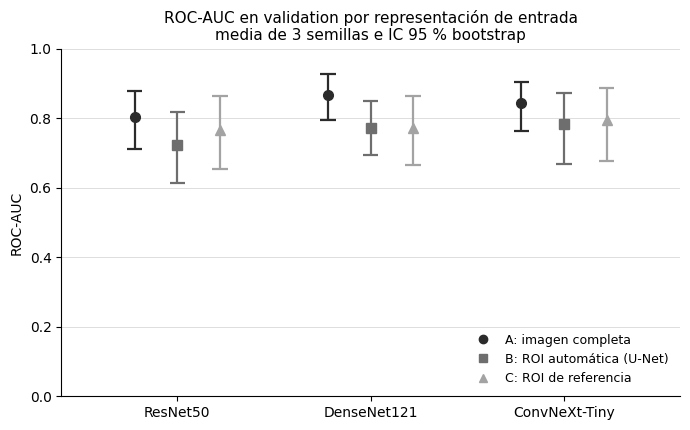

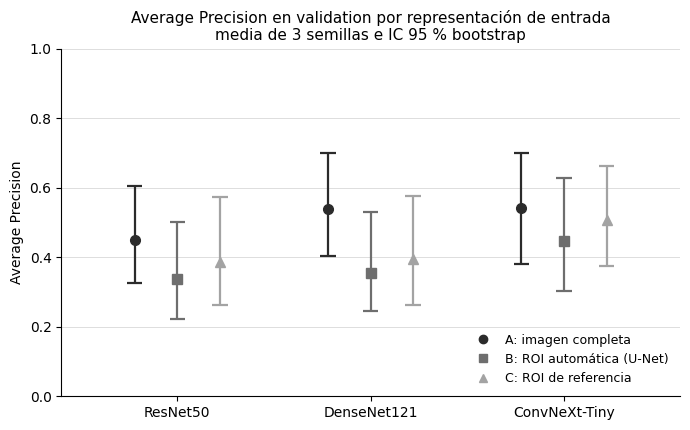

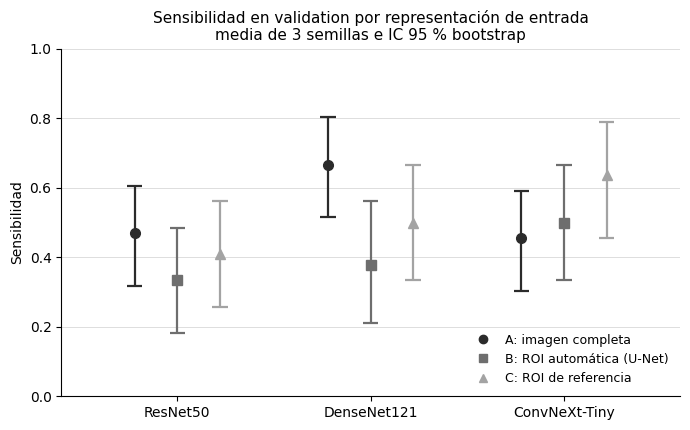

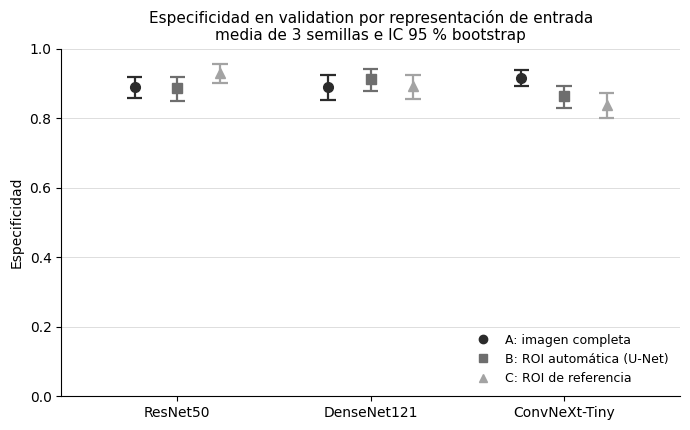

In [14]:
CONDITION_STYLES = {
    "A": {"marker": "o", "color": "#2b2b2b", "offset": -0.22},
    "B": {"marker": "s", "color": "#6e6e6e", "offset": 0.0},
    "C": {"marker": "^", "color": "#a3a3a3", "offset": 0.22},
}

FIGURE_FILES = {
    "roc_auc": "r5_roc_auc_abc_ci95.png",
    "average_precision": "r5_average_precision_abc_ci95.png",
    "sensitivity": "r5_sensitivity_abc_ci95.png",
    "specificity": "r5_specificity_abc_ci95.png",
}


def style_axis(ax):
    ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def draw_interval(ax, x, center, lower, upper, color, marker):
    ax.vlines(x, lower, upper, color=color, linewidth=1.6, zorder=2)
    ax.hlines([lower, upper], x - 0.04, x + 0.04, color=color, linewidth=1.6, zorder=2)
    ax.plot(x, center, linestyle="none", marker=marker, markersize=7, color=color, zorder=3)


def plot_metric_by_condition(metric, filename):
    rows = summary[summary["metric"] == metric].set_index(["architecture", "condition"])
    positions = np.arange(len(ARCHS))

    fig, ax = plt.subplots(figsize=(7.0, 4.4))

    for condition in CONDITIONS:
        style = CONDITION_STYLES[condition]
        for position, arch in zip(positions, ARCHS):
            row = rows.loc[(arch, condition)]
            draw_interval(ax, position + style["offset"], row["mean"], row["ci95_lower"], row["ci95_upper"],
                          style["color"], style["marker"])
        ax.plot([], [], linestyle="none", marker=style["marker"], color=style["color"], label=CONDITION_LABELS[condition])

    ax.set_xticks(positions)
    ax.set_xticklabels([ARCH_LABELS[arch] for arch in ARCHS])
    ax.set_xlim(-0.6, len(ARCHS) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(
        f"{METRIC_LABELS[metric]} en validation por representación de entrada\n"
        "media de 3 semillas e IC 95 % bootstrap",
        fontsize=11,
    )
    ax.legend(frameon=False, fontsize=9, loc="lower right")
    style_axis(ax)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


for metric in METRICS:
    plot_metric_by_condition(metric, FIGURE_FILES[metric])

### Diferencias entre condiciones (B - A y C - A)

La figura muestra, para ROC-AUC y AP, la diferencia observada respecto de la imagen completa y su IC 95 % bootstrap pareado. La línea horizontal en 0 indica ausencia de diferencia. La figura describe magnitud e incertidumbre del efecto; no constituye una prueba de superioridad.

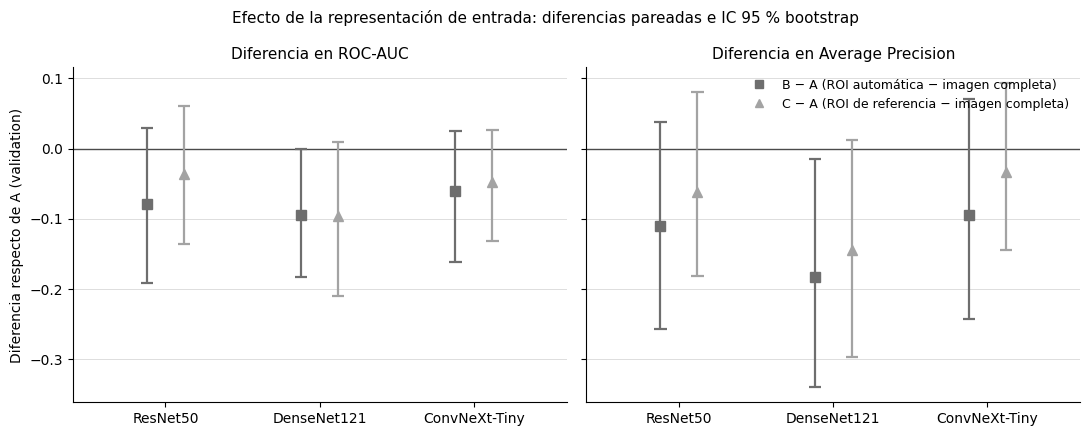

In [15]:
DIFFERENCE_CONTRASTS = {
    "B-A": {"marker": "s", "color": "#6e6e6e", "offset": -0.12, "label": "B − A (ROI automática − imagen completa)"},
    "C-A": {"marker": "^", "color": "#a3a3a3", "offset": 0.12, "label": "C − A (ROI de referencia − imagen completa)"},
}

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), sharey=True)
positions = np.arange(len(ARCHS))
rows = difference_summary.set_index(["architecture", "contrast", "metric"])

for ax, metric in zip(axes, ["roc_auc", "average_precision"]):
    ax.axhline(0, color="#4a4a4a", linewidth=1.0, zorder=1)

    for contrast, style in DIFFERENCE_CONTRASTS.items():
        for position, arch in zip(positions, ARCHS):
            row = rows.loc[(arch, contrast, metric)]
            draw_interval(ax, position + style["offset"], row["observed_difference"], row["ci95_lower"], row["ci95_upper"],
                          style["color"], style["marker"])
        ax.plot([], [], linestyle="none", marker=style["marker"], color=style["color"], label=style["label"])

    ax.set_xticks(positions)
    ax.set_xticklabels([ARCH_LABELS[arch] for arch in ARCHS])
    ax.set_xlim(-0.6, len(ARCHS) - 0.4)
    ax.set_title(f"Diferencia en {METRIC_LABELS[metric]}", fontsize=11)
    style_axis(ax)

axes[0].set_ylabel("Diferencia respecto de A (validation)")
axes[1].legend(frameon=False, fontsize=9, loc="best")
fig.suptitle("Efecto de la representación de entrada: diferencias pareadas e IC 95 % bootstrap", fontsize=11)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "r5_differences_vs_a_auc_ap_ci95.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
for path in sorted(OUTPUT_DIR.glob("*.csv")) + sorted(FIGURES_DIR.glob("*.png")):
    print(path.relative_to(PROJECT_ROOT).as_posix())

results/classification/r5_input_representation/analysis/r5_bootstrap_differences.csv
results/classification/r5_input_representation/analysis/r5_bootstrap_means.csv
results/classification/r5_input_representation/analysis/r5_condition_differences.csv
results/classification/r5_input_representation/analysis/r5_condition_summary.csv
results/classification/r5_input_representation/analysis/r5_condition_summary_wide.csv
results/classification/r5_input_representation/analysis/r5_metrics_per_seed.csv
results/classification/r5_input_representation/analysis/r5_run_validation.csv
results/classification/r5_input_representation/analysis/figures/r5_average_precision_abc_ci95.png
results/classification/r5_input_representation/analysis/figures/r5_differences_vs_a_auc_ap_ci95.png
results/classification/r5_input_representation/analysis/figures/r5_roc_auc_abc_ci95.png
results/classification/r5_input_representation/analysis/figures/r5_sensitivity_abc_ci95.png
results/classification/r5_input_representation/a